In [1]:
import os
import json
from dotenv import load_dotenv

load_dotenv()

checks = {
    "GROQ_API_KEY": os.getenv("GROQ_API_KEY"),
    "HUGGINGFACE_API_TOKEN": os.getenv("HUGGINGFACE_API_TOKEN"),
    "ASTRA_DB_APPLICATION_TOKEN": os.getenv("ASTRA_DB_APPLICATION_TOKEN"),
    "ASTRA_DB_API_ENDPOINT": os.getenv("ASTRA_DB_API_ENDPOINT"),
    "DATABASE_URL": os.getenv("DATABASE_URL"),
}

#### Agent State


In [2]:
from typing import TypedDict, Literal, Optional
from langchain_core.messages import BaseMessage


class AgentState(TypedDict):
    user_id: str
    query: str
    image: Optional[str]
    file_path: Optional[str]

    # Route
    intent: Optional[Literal["ingest", "rag_query", "support_query"]]
    confidence: Optional[float]

    # RAG
    chunks: Optional[list[str]]
    sources: Optional[list[dict]]
    retrieved_docs: Optional[list[str]]

    # Support
    ticket_category: Optional[str]
    ticket_id: Optional[str]
    escalate: Optional[bool]

    # Output
    messages: list[BaseMessage]
    final_response: Optional[str]


print("✅ AgentState defined")
print("Fields:", list(AgentState.__annotations__.keys()))

✅ AgentState defined
Fields: ['user_id', 'query', 'image', 'file_path', 'intent', 'confidence', 'chunks', 'sources', 'retrieved_docs', 'ticket_category', 'ticket_id', 'escalate', 'messages', 'final_response']


#### Intent Node


In [3]:
from groq import Groq

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

INTENT_SYSTEM_PROMPT = """
You are an intent classifier for an AI assistant called SageDesk.
Your job is to classify the user's query into exactly one of three intents:

1. "ingest"        — user wants to upload / add a document to the knowledge base
2. "rag_query"     — user wants to retrieve information or get an answer from existing documents
                    NOTE: questions asking WHAT, HOW, WHY, WHEN about a topic are ALWAYS rag_query
                    even if they sound like a complaint or support issue
3. "support_query" — user has a PERSONAL problem that needs human/agent intervention
                    NOTE: support_query is only when the user is describing THEIR OWN specific problem
                    not when they are asking a general information question

Key rules:
- "What is X?" → ALWAYS rag_query
- "How do I X?" → ALWAYS rag_query (asking for instructions, not reporting a problem)
- "I want to / I need to X" → support_query ONLY if it requires account intervention
- "I have a problem with X" → ALWAYS support_query
- "I [past tense personal event]" → ALWAYS support_query (e.g. "I was charged", "I missed")

Respond ONLY with a valid JSON object in this exact format — no preamble, no explanation:
{
    "intent": "rag_query",
    "confidence": 0.95,
    "reasoning": "one short sentence"
}
"""


def classify_intent(query: str) -> dict:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": INTENT_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ],
        temperature=0.1,
    )

    raw = response.choices[0].message.content.strip()

    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        import re

        match = re.search(r"\{.*\}", raw, re.DOTALL)
        if match:
            result = json.loads(match.group())
        else:
            raise ValueError(f"Could not parse intent response: {raw}")

    return result


def intent_node(state: AgentState) -> dict:
    query = state["query"]
    result = classify_intent(query=query)
    intent = result.get("intent", "rag_query")
    confidence = result.get("confidence", 0.0)

    valid_intents = {"ingest", "rag_query", "support_query"}
    if intent not in valid_intents:
        intent = "rag_query"
        confidence = 0.0

    print(f"✅ intent_node → intent: {intent}  confidence: {confidence}")

    return {
        "intent": intent,
        "confidence": confidence,
    }

In [4]:
state = {"user_id": "1", "query": "How do I reset my password?"}

result = intent_node(state)
print(result)

✅ intent_node → intent: rag_query  confidence: 0.95
{'intent': 'rag_query', 'confidence': 0.95}


#### Ingest Node


In [5]:
from typing import Optional
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\Prashant\AppData\Local\Temp\ipykernel_27376\1225394732.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader
d:\ai-learning\sagedesk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def load_documents(file_path: str) -> list:
    extension = Path(file_path).suffix.lower()
    if extension == ".pdf":
        loader = PyPDFLoader(file_path)
    elif extension == ".docx":
        loader = Docx2txtLoader(file_path)
    elif extension == ".txt":
        loader = TextLoader(file_path)
    else:
        raise ValueError(f"Unsupported file type : {extension}")

    return loader.load()

In [7]:
def ingest_node(state: AgentState) -> dict:
    file_path = state["file_path"]

    if not file_path:
        print("No file_path in state - skipping ingest")
        return {"chunks": [], "sources": []}

    print(f"Loading documents : {file_path}")

    docs = load_documents(file_path=file_path)
    print(f"Loaded {len(docs)} pages")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=256,
        chunk_overlap=64,
        separators=["\n\n", "\n", ".", " "],
    )

    split_docs = splitter.split_documents(docs)
    print(f"Splitted in {len(split_docs)} chunks")

    chunks = [doc.page_content for doc in split_docs]
    sources = [
        {
            "filename": Path(file_path).name,
            "page": doc.metadata.get("page", 0),
            "chunk_index": i,
            "char_count": len(doc.page_content),
        }
        for i, doc in enumerate(split_docs)
    ]
    print(f"Ingest node -> {len(chunks)} chunks ready")
    return {"chunks": chunks, "sources": sources}

In [8]:
test_doc_path = Path.cwd().parent / "test_doc.txt"

test_doc_path.write_text("""
# SageDesk Refund Policy

## Overview
SageDesk offers a 30-day money-back guarantee on all subscription plans.
If you are not satisfied with our service, you can request a full refund
within 30 days of your initial purchase.

## Eligibility
To be eligible for a refund, you must:
- Submit a refund request within 30 days of purchase
- Not have exceeded the usage limits of the free tier
- Provide a reason for the refund request

## How to Request a Refund
1. Log in to your SageDesk account
2. Navigate to Billing settings
3. Click on Request Refund
4. Fill out the refund form
5. Submit and wait 3-5 business days for processing

## Non-Refundable Items
The following are not eligible for refunds:
- Add-on purchases older than 30 days
- Custom enterprise contracts
- Usage-based billing charges

## Contact
For refund questions email support@sagedesk.ai
""")

print(f"✅ Test document created at: {test_doc_path}")

✅ Test document created at: d:\ai-learning\sagedesk\test_doc.txt


In [9]:
# add file_path to our test state temporarily
test_state_with_file = {
    **state,
    "file_path": str(test_doc_path),
}

result = ingest_node(test_state_with_file)

print(f"\nTotal chunks:  {len(result['chunks'])}")
print(f"Total sources: {len(result['sources'])}")
print("\n── First chunk ──────────────────────────")
print(result["chunks"][0])
print("\n── First source metadata ────────────────")
print(result["sources"][0])

Loading documents : d:\ai-learning\sagedesk\test_doc.txt
Loaded 1 pages
Splitted in 4 chunks
Ingest node -> 4 chunks ready

Total chunks:  4
Total sources: 4

── First chunk ──────────────────────────
# SageDesk Refund Policy

## Overview
SageDesk offers a 30-day money-back guarantee on all subscription plans.
If you are not satisfied with our service, you can request a full refund
within 30 days of your initial purchase.

── First source metadata ────────────────
{'filename': 'test_doc.txt', 'page': 0, 'chunk_index': 0, 'char_count': 224}


#### Embed Node


In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_astradb import AstraDBVectorStore
from langchain_core.documents import Document

In [11]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    encode_kwargs={"normalize_embeddings": True},
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11745.24it/s]


In [12]:
vector_store = AstraDBVectorStore(
    embedding=embeddings,
    collection_name=os.getenv("ASTRA_DB_COLLECTION"),
    token=os.getenv("ASTRA_DB_APPLICATION_TOKEN"),
    api_endpoint=os.getenv("ASTRA_DB_API_ENDPOINT"),
)

In [13]:
def embed_node(state: AgentState) -> dict:
    chunks = state.get("chunks")
    sources = state.get("sources")

    if not chunks:
        print("No chunks in state — skipping embed")
        return {}

    print(f"Embedding {len(chunks)} chunks...")

    documents = [
        Document(
            page_content=chunk,
            metadata=sources[i] if sources and i < len(sources) else {},
        )
        for i, chunk in enumerate(chunks)
    ]

    inserted_ids = vector_store.add_documents(documents)
    print(f"embed_node → {len(inserted_ids)} chunks upserted to AstraDB")
    return {}

In [14]:
# use the result from ingest_node
embed_state = {
    **state,
    "file_path": str(test_doc_path),
    "chunks": result["chunks"],
    "sources": result["sources"],
}

embed_result = embed_node(embed_state)
print("Done:", embed_result)

Embedding 4 chunks...
embed_node → 4 chunks upserted to AstraDB
Done: {}


In [15]:
test_search = vector_store.similarity_search(
    query="refund policy",
    k=2,
)

print(f"✅ Found {len(test_search)} results in AstraDB\n")
for i, doc in enumerate(test_search, 1):
    print(f"── Result {i} ───────────────────────────")
    print(f"Content:  {doc.page_content[:200]}")
    print(f"Metadata: {doc.metadata}")
    print()

✅ Found 2 results in AstraDB

── Result 1 ───────────────────────────
Content:  ## Non-Refundable Items
The following are not eligible for refunds:
- Add-on purchases older than 30 days
- Custom enterprise contracts
- Usage-based billing charges

## Contact
For refund questions e
Metadata: {'filename': 'test_doc.txt', 'page': 0, 'chunk_index': 3, 'char_count': 224}

── Result 2 ───────────────────────────
Content:  ## Non-Refundable Items
The following are not eligible for refunds:
- Add-on purchases older than 30 days
- Custom enterprise contracts
- Usage-based billing charges

## Contact
For refund questions e
Metadata: {'filename': 'test_doc.txt', 'page': 0, 'chunk_index': 3, 'char_count': 224}



#### Retrieval Node


In [16]:
def retrieval_node(state: AgentState) -> dict:
    query = state.get("query")
    if not query:
        print("No query in state — skipping retrieval")
        return {"retrieved_docs": [], "sources": []}

    print(f"Searching AstraDB for : {query}")
    results = vector_store.similarity_search_with_score(query=query, k=3)
    if not results:
        print("No results found in AstraDB")
        return {"retrieved_docs": [], "sources": []}

    retrieved_docs = []
    sources = []

    for doc, score in results:
        retrieved_docs.append(doc.page_content)
        sources.append({**doc.metadata, "similarity_score": round(score, 4)})
        print(f"Score: {round(score, 4)} | Chunk: {doc.page_content[:80]}")

    print(f"retrieval_node → {len(retrieved_docs)} chunks retrieved")
    return {
        "retrieved_docs": retrieved_docs,
        "sources": sources,
    }

In [17]:
test_retrieval_queries = [
    "What is the refund policy?",
    "How do I request a refund?",
    "What items are not eligible for refund?",
    "How long does refund processing take?",
]

for query in test_retrieval_queries:
    print(f"\n{'=' * 60}")
    print(f"Query: {query}")
    print("=" * 60)

    retrieval_state = {
        **state,
        "query": query,
    }

    retrieval_result = retrieval_node(retrieval_state)

    print(f"\nRetrieved {len(retrieval_result['retrieved_docs'])} chunks")
    for i, (doc, src) in enumerate(
        zip(retrieval_result["retrieved_docs"], retrieval_result["sources"]), 1
    ):
        print(f"\n── Chunk {i} (score: {src['similarity_score']}) ──")
        print(doc[:200])


Query: What is the refund policy?
Searching AstraDB for : What is the refund policy?
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7945 | Chunk: ## Non-Refundable Items
The following are not eligible for refunds:
- Add-on pur
retrieval_node → 3 chunks retrieved

Retrieved 3 chunks

── Chunk 1 (score: 0.7965) ──
## Eligibility
To be eligible for a refund, you must:
- Submit a refund request within 30 days of purchase
- Not have exceeded the usage limits of the free tier
- Provide a reason for the refund reque

── Chunk 2 (score: 0.7965) ──
## Eligibility
To be eligible for a refund, you must:
- Submit a refund request within 30 days of purchase
- Not have exceeded the usage limits of the free tier
- Provide a reason for the refund reque

── Chunk 3 (score: 0.7945) ──
## Non-Refundable Items
The following are not eligi

In [18]:
print("Testing query with no relevant context...\n")

off_topic_state = {
    **state,
    "query": "What is the weather in Bangalore today?",
}

off_topic_result = retrieval_node(off_topic_state)

print(f"\nRetrieved {len(off_topic_result['retrieved_docs'])} chunks")
if off_topic_result["retrieved_docs"]:
    for src in off_topic_result["sources"]:
        print(f"Score: {src['similarity_score']} — {src['filename']}")

Testing query with no relevant context...

Searching AstraDB for : What is the weather in Bangalore today?
Score: 0.4808 | Chunk: ## How to Request a Refund
1. Log in to your SageDesk account
2. Navigate to Bil
Score: 0.4808 | Chunk: ## How to Request a Refund
1. Log in to your SageDesk account
2. Navigate to Bil
Score: 0.4749 | Chunk: # SageDesk Refund Policy

## Overview
SageDesk offers a 30-day money-back guaran
retrieval_node → 3 chunks retrieved

Retrieved 3 chunks
Score: 0.4808 — test_doc.txt
Score: 0.4808 — test_doc.txt
Score: 0.4749 — test_doc.txt


#### Generate Node


In [19]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

SIMILARITY_THRESHOLD = 0.70

RAG_SYSTEM_PROMPT = """
You are SageDesk, a helpful AI assistant that answers questions
strictly based on the provided context documents.

Rules:
1. Answer ONLY from the provided context — do not use outside knowledge
2. If the context does not contain enough information, say: "I don't have information about that in my knowledge base."
3. Always cite your source at the end using this format: Source: filename (from metadata), Page [page number]
Use the actual filename from the chunk metadata, not a placeholder.
4. Be concise and direct — no unnecessary filler
5. If multiple chunks are relevant, synthesise them into one clear answer
"""

llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.3-70b-versatile",
    temperature=0.2,
)

In [20]:
def build_context(
    retrieved_docs: list[str], sources: list[dict]
) -> tuple[str, list[dict]]:
    filtered_docs = []
    filtered_sources = []

    for doc, src in zip(retrieved_docs, sources):
        score = src.get("similarity_score", 0)
        if score >= SIMILARITY_THRESHOLD:
            filtered_docs.append(doc)
            filtered_sources.append(src)
        else:
            print(f"Discarded chunk (score: {score}) — below threshold")

    if not filtered_docs:
        return "", []

    context = "\n\n---\n\n".join(
        [f"[Chunk {i + 1}]\n{doc}" for i, doc in enumerate(filtered_docs)]
    )

    return context, filtered_sources

In [21]:
def generate_node(state: AgentState) -> dict:
    query = state.get("query")
    retrieved_docs = state.get("retrieved_docs", [])
    sources = state.get("sources", [])
    messages = state.get("messages", [])

    if not query:
        return {"final_response": "No query provided."}
    print(f"Generating answer for: '{query}'")
    context, filtered_sources = build_context(retrieved_docs, sources)
    if not context:
        response_text = "I don't have information about that in my knowledge base."
        print("generate_node → No relevant context found")
    else:
        user_prompt = f"""
            Context: 
            {context}
            
            Question: 
            {query}

            Answer based strictly on the context above.
        """
        response = llm.invoke(
            [
                SystemMessage(content=RAG_SYSTEM_PROMPT),
                HumanMessage(content=user_prompt),
            ]
        )
        response_text = response.content
    updated_messages = messages + [AIMessage(content=response_text)]
    return {
        "final_response": response_text,
        "messages": updated_messages,
    }


In [22]:
relevant_queries = [
    "What is the refund policy?",
    "How do I request a refund?",
    "What items are not eligible for refund?",
]

for query in relevant_queries:
    print(f"\n{'=' * 60}")
    print(f"Query: {query}")
    print("=" * 60)

    # first retrieve
    retrieval_state = {**state, "query": query}
    retrieval_result = retrieval_node(retrieval_state)

    # then generate
    generate_state = {
        **state,
        "query": query,
        "retrieved_docs": retrieval_result["retrieved_docs"],
        "sources": retrieval_result["sources"],
        "messages": [HumanMessage(content=query)],
    }
    generate_result = generate_node(generate_state)

    print("\n── Answer ───────────────────────────────")
    print(generate_result["final_response"])


Query: What is the refund policy?
Searching AstraDB for : What is the refund policy?
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7945 | Chunk: ## Non-Refundable Items
The following are not eligible for refunds:
- Add-on pur
retrieval_node → 3 chunks retrieved
Generating answer for: 'What is the refund policy?'

── Answer ───────────────────────────────
To be eligible for a refund, you must submit a refund request within 30 days of purchase, not have exceeded the usage limits of the free tier, and provide a reason for the refund request. However, certain items are not eligible for refunds, including add-on purchases older than 30 days, custom enterprise contracts, and usage-based billing charges.

Source: Chunk 1, Page 1, Chunk 2, Page 1, Chunk 3, Page 1

Query: How do I request a refund?
Searching AstraDB for : How

#### Classify Node


In [23]:
CLASSIFY_SYSTEM_PROMPT = """
You are a customer support ticket classifier for SageDesk.
Your job is to classify the user's support query into exactly one category:

1. "faq"        — common question that can be answered from documentation
2. "bug"        — technical issue or unexpected behaviour in the product
3. "billing"    — payment, subscription, or charge related issues
4. "escalation" — urgent, sensitive, or unresolved issue needing human intervention

Escalation rules — set escalate to true if ANY of these apply:
- User explicitly asks for a human / manager
- User mentions legal action or complaints
- User says they have contacted support multiple times
- User is extremely frustrated or uses urgent language
- Billing issues where money was deducted unexpectedly
- User's account is locked or has other issues regarding security

Respond ONLY with valid JSON — no preamble, no explanation:
{
    "ticket_category": "billing",
    "escalate": false,
    "priority": "medium",
    "reasoning": "one short sentence"
}

Priority levels: "low", "medium", "high", "critical"
"""

In [24]:
def classify_node(state: AgentState) -> dict:
    query = state.get("query")
    if not query:
        print("No query in state — skipping classify")
        return {
            "ticket_category": "faq",
            "escalate": False,
        }
    print(f"Classifying support query: '{query}'")

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": CLASSIFY_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ],
        temperature=0.1,
    )

    raw = response.choices[0].message.content.strip()

    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        import re

        match = re.search(r"\{.*\}", raw, re.DOTALL)
        if match:
            result = json.loads(match.group())
        else:
            raise ValueError(f"Could not parse classify response: {raw}")

    ticket_category = result.get("ticket_category", "faq")
    escalate = result.get("escalate", False)
    priority = result.get("priority", "medium")
    reasoning = result.get("reasoning", "")

    print(
        f"classify_node → category: {ticket_category} | escalate: {escalate} | priority: {priority}"
    )
    print(f"Reasoning: {reasoning}")
    return {
        "ticket_category": ticket_category,
        "escalate": escalate,
    }

In [25]:
support_queries = [
    # faq
    "How do I reset my password?",
    "Where can I find my invoices?",
    # bug
    "The app keeps crashing when I upload a PDF",
    "I'm getting a 500 error when I try to login",
    # billing
    "I was charged twice this month",
    "My payment failed but money was deducted",
    # escalation
    "I have contacted support 3 times and nobody has helped me",
    "I want to speak to a manager right now",
    "I am going to take legal action if this is not resolved",
    "This is extremely urgent, my entire team is blocked",
]

print(f"{'Query':<50} {'Category':<12} {'Escalate':<10} {'Priority'}")
print("-" * 90)

for query in support_queries:
    result = classify_node({**state, "query": query})
    # re-run just for table display
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": CLASSIFY_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ],
        temperature=0.1,
    )
    r = json.loads(response.choices[0].message.content.strip())
    print(
        f"{query:<50} {r['ticket_category']:<12} {str(r['escalate']):<10} {r['priority']}"
    )

Query                                              Category     Escalate   Priority
------------------------------------------------------------------------------------------
Classifying support query: 'How do I reset my password?'
classify_node → category: faq | escalate: False | priority: low
Reasoning: Password reset is a common question answered in documentation
How do I reset my password?                        faq          False      low
Classifying support query: 'Where can I find my invoices?'
classify_node → category: faq | escalate: False | priority: low
Reasoning: User is asking for information that can be found in documentation
Where can I find my invoices?                      faq          False      low
Classifying support query: 'The app keeps crashing when I upload a PDF'
classify_node → category: bug | escalate: False | priority: medium
Reasoning: App crashing is a technical issue.
The app keeps crashing when I upload a PDF         bug          False      medium
Classi

In [26]:
edge_cases = [
    "I think I was overcharged but I'm not sure",  # billing, maybe escalation
    "The app is a bit slow sometimes",  # bug, low priority
    "URGENT!!! My account is locked I need help NOW",  # escalation, critical
    "Can someone call me back please?",  # escalation — wants human
    "I accidentally deleted my documents",  # bug or faq
]

print("\nEdge Cases:")
print(f"{'Query':<55} {'Category':<12} {'Escalate':<10} {'Priority'}")
print("-" * 95)

for query in edge_cases:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": CLASSIFY_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ],
        temperature=0.1,
    )
    r = json.loads(response.choices[0].message.content.strip())
    print(
        f"{query:<55} {r['ticket_category']:<12} {str(r['escalate']):<10} {r['priority']}"
    )


Edge Cases:
Query                                                   Category     Escalate   Priority
-----------------------------------------------------------------------------------------------
I think I was overcharged but I'm not sure              billing      False      medium
The app is a bit slow sometimes                         bug          False      low
URGENT!!! My account is locked I need help NOW          escalation   True       critical
Can someone call me back please?                        escalation   True       high
I accidentally deleted my documents                     bug          False      high


In [27]:
import psycopg2
import uuid
from datetime import datetime


def get_connection():
    return psycopg2.connect(os.getenv("DATABASE_URL"))

In [28]:
def generate_ticket_id() -> str:
    """Generate a readable ticket ID like TKT-2025-A3F2."""
    suffix = uuid.uuid4().hex[:4].upper()
    year = datetime.now().year
    return f"TKT-{year}-{suffix}"

In [29]:
def ticket_node(state: AgentState) -> dict:
    query = state.get("query")
    user_id = state.get("user_id", "anonymous")
    ticket_category = state.get("ticket_category", "faq")
    escalate = state.get("escalate", False)

    if not query:
        print("No query in state — skipping ticket creation")
        return {}

    priority_map = {
        ("faq", False): "low",
        ("bug", False): "medium",
        ("bug", True): "critical",
        ("billing", False): "medium",
        ("billing", True): "high",
        ("escalation", False): "high",
        ("escalation", True): "critical",
    }

    priority = priority_map.get((ticket_category, escalate), "medium")
    ticket_id = generate_ticket_id()

    print(f"Creating ticket {ticket_id}...")
    print(f"User:     {user_id}")
    print(f"Category: {ticket_category}")
    print(f"Priority: {priority}")
    print(f"Escalate: {escalate}")

    conn = get_connection()
    cur = conn.cursor()

    cur.execute(
        """
        INSERT INTO tickets (
            ticket_id, user_id, query,
            ticket_category, priority, escalate,
            status, created_at, updated_at
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
        RETURNING id;
    """,
        (
            ticket_id,
            user_id,
            query,
            ticket_category,
            priority,
            escalate,
            "open",
            datetime.now(),
            datetime.now(),
        ),
    )

    db_id = cur.fetchone()[0]
    conn.commit()
    cur.close()
    conn.close()

    print(f"✅ ticket_node → Ticket {ticket_id} saved (db id: {db_id})")

    return {
        "ticket_id": ticket_id,
        "escalate": escalate,
    }


In [31]:
test_support_cases = [
    {
        "query": "I was charged twice this month",
        "ticket_category": "billing",
        "escalate": False,
    },
    {
        "query": "App crashes when uploading PDF",
        "ticket_category": "bug",
        "escalate": False,
    },
    {
        "query": "I want to speak to a manager right now",
        "ticket_category": "escalation",
        "escalate": True,
    },
]

created_tickets = []

for case in test_support_cases:
    ticket_state = {
        **state,
        "query": case["query"],
        "ticket_category": case["ticket_category"],
        "escalate": case["escalate"],
    }
    ticket_state["user_id"] = "user_001"
    result = ticket_node(ticket_state)
    created_tickets.append(result["ticket_id"])
    print()

Creating ticket TKT-2026-D230...
User:     user_001
Category: billing
Priority: medium
Escalate: False
✅ ticket_node → Ticket TKT-2026-D230 saved (db id: 4)

Creating ticket TKT-2026-AB2D...
User:     user_001
Category: bug
Priority: medium
Escalate: False
✅ ticket_node → Ticket TKT-2026-AB2D saved (db id: 5)

Creating ticket TKT-2026-5EEA...
User:     user_001
Category: escalation
Priority: critical
Escalate: True
✅ ticket_node → Ticket TKT-2026-5EEA saved (db id: 6)



#### Response Node


In [32]:
def response_node(state: AgentState) -> dict:
    intent = state.get("intent")
    final_response = state.get("final_response")
    ticket_id = state.get("ticket_id")
    ticket_category = state.get("ticket_category")
    escalate = state.get("escalate", False)
    messages = state.get("messages", [])
    query = state.get("query", "")

    print(f"Formatting response for intent: {intent}")
    if intent in ("rag_query", "ingest"):
        if intent == "ingest":
            response_text = (
                "Your document has been successfully ingested "
                "into the knowledge base and is ready for querying."
            )
        else:
            if final_response:
                response_text = final_response
            else:
                response_text = (
                    "I couldn't find relevant information "
                    "in the knowledge base for your query."
                )
    elif intent == "support_query":
        if escalate:
            response_text = (
                f"I understand this is urgent and I'm sorry for the trouble. "
                f"Your case has been escalated to our senior support team.\n\n"
                f"🎫 Ticket ID: {ticket_id}\n"
                f"⚡ Priority: Critical\n"
                f"A senior agent will contact you within 1 hour."
            )
        else:
            category_eta = {
                "faq": "We'll respond within 24 hours.",
                "bug": "Our engineering team will investigate within 48 hours.",
                "billing": "Our billing team will resolve this within 24 hours.",
            }
            eta = category_eta.get(ticket_category, "We'll respond shortly.")
            response_text = (
                f"Thank you for reaching out. Your support ticket has been created.\n\n"
                f"🎫 Ticket ID: {ticket_id}\n"
                f"📋 Category: {ticket_category.capitalize()}\n"
                f"{eta}"
            )
    else:
        response_text = (
            "I'm not sure how to handle that request. "
            "Please try rephrasing or contact support directly."
        )

    updated_messages = messages + [AIMessage(content=response_text)]

    print("response_node → Response formatted")
    print("\n── Final Response ───────────────────────────")
    print(response_text)

    return {
        "final_response": response_text,
        "messages": updated_messages,
    }

In [34]:
# simulate state after RAG generate_node
rag_state = {
    **state,
    "intent": "rag_query",
    "query": "What is the refund policy?",
    "final_response": (
        "SageDesk offers a 30-day money-back guarantee. "
        "To be eligible you must submit within 30 days of purchase.\n\n"
        "Source: test_doc.txt, Page 0"
    ),
    "messages": [HumanMessage(content="What is the refund policy?")],
}

rag_response = response_node(rag_state)

Formatting response for intent: rag_query
response_node → Response formatted

── Final Response ───────────────────────────
SageDesk offers a 30-day money-back guarantee. To be eligible you must submit within 30 days of purchase.

Source: test_doc.txt, Page 0


In [35]:
support_state = {
    **state,
    "intent": "support_query",
    "query": "App keeps crashing when I upload a PDF",
    "ticket_id": "TKT-2026-FA82",
    "ticket_category": "bug",
    "escalate": False,
    "messages": [HumanMessage(content="App keeps crashing when I upload a PDF")],
}

support_response = response_node(support_state)

Formatting response for intent: support_query
response_node → Response formatted

── Final Response ───────────────────────────
Thank you for reaching out. Your support ticket has been created.

🎫 Ticket ID: TKT-2026-FA82
📋 Category: Bug
Our engineering team will investigate within 48 hours.


In [36]:
escalation_state = {
    **state,
    "intent": "support_query",
    "query": "I want to speak to a manager right now",
    "ticket_id": "TKT-2026-4B69",
    "ticket_category": "escalation",
    "escalate": True,
    "messages": [HumanMessage(content="I want to speak to a manager right now")],
}

escalation_response = response_node(escalation_state)

Formatting response for intent: support_query
response_node → Response formatted

── Final Response ───────────────────────────
I understand this is urgent and I'm sorry for the trouble. Your case has been escalated to our senior support team.

🎫 Ticket ID: TKT-2026-4B69
⚡ Priority: Critical
A senior agent will contact you within 1 hour.


In [37]:
# simulate state after embed_node
ingest_state = {
    **state,
    "intent": "ingest",
    "query": "Upload this PDF to the knowledge base",
    "messages": [HumanMessage(content="Upload this PDF to the knowledge base")],
}

ingest_response = response_node(ingest_state)

Formatting response for intent: ingest
response_node → Response formatted

── Final Response ───────────────────────────
Your document has been successfully ingested into the knowledge base and is ready for querying.


#### Graph


In [38]:
from langgraph.graph import StateGraph, END

In [39]:
def route_intent(state: AgentState) -> str:
    intent = state.get("intent")
    confidence = state.get("confidence", 0.0)

    if confidence < 0.70:
        print(f"Low confidence ({confidence}) — defaulting to rag_query")
        return "retrieval_node"

    if intent == "ingest":
        return "ingest_node"
    elif intent == "rag_query":
        return "retrieval_node"
    elif intent == "support_query":
        return "classify_node"
    else:
        return "retrieval_node"


def build_graph():
    graph = StateGraph(AgentState)

    graph.add_node("intent_node", intent_node)
    graph.add_node("ingest_node", ingest_node)
    graph.add_node("embed_node", embed_node)
    graph.add_node("retrieval_node", retrieval_node)
    graph.add_node("generate_node", generate_node)
    graph.add_node("classify_node", classify_node)
    graph.add_node("ticket_node", ticket_node)
    graph.add_node("response_node", response_node)

    graph.set_entry_point("intent_node")

    graph.add_conditional_edges(
        "intent_node",
        route_intent,
        {
            "ingest_node": "ingest_node",
            "retrieval_node": "retrieval_node",
            "classify_node": "classify_node",
        },
    )

    graph.add_edge("ingest_node", "embed_node")
    graph.add_edge("embed_node", "response_node")

    graph.add_edge("retrieval_node", "generate_node")
    graph.add_edge("generate_node", "response_node")

    graph.add_edge("classify_node", "ticket_node")
    graph.add_edge("ticket_node", "response_node")

    graph.add_edge("response_node", END)

    return graph.compile()

In [40]:
sagedesk = build_graph()

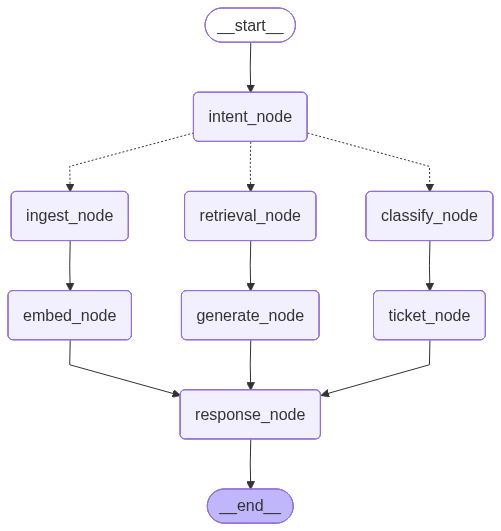

In [41]:
from IPython.display import Image, display

display(Image(sagedesk.get_graph().draw_mermaid_png()))

In [42]:
print("=" * 60)
print("TEST 1 — RAG Query")
print("=" * 60)

rag_input: AgentState = {
    "user_id": "user_001",
    "query": "What is the refund policy?",
    "messages": [HumanMessage(content="What is the refund policy?")],
}
result = sagedesk.invoke(rag_input)
print(result["final_response"])
print(f"\n── Messages in history: {len(result['messages'])}")

TEST 1 — RAG Query
✅ intent_node → intent: rag_query  confidence: 0.95
Searching AstraDB for : What is the refund policy?
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7965 | Chunk: ## Eligibility
To be eligible for a refund, you must:
- Submit a refund request 
Score: 0.7945 | Chunk: ## Non-Refundable Items
The following are not eligible for refunds:
- Add-on pur
retrieval_node → 3 chunks retrieved
Generating answer for: 'What is the refund policy?'
Formatting response for intent: rag_query
response_node → Response formatted

── Final Response ───────────────────────────
To be eligible for a refund, you must submit a refund request within 30 days of purchase, not have exceeded the usage limits of the free tier, and provide a reason for the refund request. However, certain items are not eligible for refunds, including add-on purchases older than 30 days, custom enterprise contracts, and usage-based billing charges.

Sou

In [43]:
print("=" * 60)
print("TEST 2 — Support Query")
print("=" * 60)

support_input: AgentState = {
    "user_id":          "user_001",
    "query":            "I was charged twice this month",
    "messages":         [HumanMessage(content="I was charged twice this month")],
}

result = sagedesk.invoke(support_input)

print(result["final_response"])
print(f"\n── Ticket ID: {result['ticket_id']}")
print(f"── Category:  {result['ticket_category']}")
print(f"── Escalate:  {result['escalate']}")

TEST 2 — Support Query
✅ intent_node → intent: support_query  confidence: 0.99
Classifying support query: 'I was charged twice this month'
classify_node → category: billing | escalate: True | priority: high
Reasoning: User was unexpectedly charged twice.
Creating ticket TKT-2026-839F...
User:     user_001
Category: billing
Priority: high
Escalate: True
✅ ticket_node → Ticket TKT-2026-839F saved (db id: 7)
Formatting response for intent: support_query
response_node → Response formatted

── Final Response ───────────────────────────
I understand this is urgent and I'm sorry for the trouble. Your case has been escalated to our senior support team.

🎫 Ticket ID: TKT-2026-839F
⚡ Priority: Critical
A senior agent will contact you within 1 hour.
I understand this is urgent and I'm sorry for the trouble. Your case has been escalated to our senior support team.

🎫 Ticket ID: TKT-2026-839F
⚡ Priority: Critical
A senior agent will contact you within 1 hour.

── Ticket ID: TKT-2026-839F
── Categor

In [44]:
print("=" * 60)
print("TEST 3 — Document Ingest")
print("=" * 60)

ingest_input: AgentState = {
    "user_id":          "user_001",
    "query":            "Upload this document to the knowledge base",
    "file_path":        str(test_doc_path),
    "messages":         [HumanMessage(content="Upload this document")],
}

result = sagedesk.invoke(ingest_input)

print(result["final_response"])
print(f"\n── Chunks ingested: {len(result['chunks']) if result['chunks'] else 0}")

TEST 3 — Document Ingest
✅ intent_node → intent: ingest  confidence: 0.99
Loading documents : d:\ai-learning\sagedesk\test_doc.txt
Loaded 1 pages
Splitted in 4 chunks
Ingest node -> 4 chunks ready
Embedding 4 chunks...
embed_node → 4 chunks upserted to AstraDB
Formatting response for intent: ingest
response_node → Response formatted

── Final Response ───────────────────────────
Your document has been successfully ingested into the knowledge base and is ready for querying.
Your document has been successfully ingested into the knowledge base and is ready for querying.

── Chunks ingested: 4


In [45]:
print("=" * 60)
print("TEST 4 — Escalation")
print("=" * 60)

escalation_input: AgentState = {
    "user_id":          "user_001",
    "query":            "I want to speak to a manager right now",
    "messages":         [HumanMessage(content="I want to speak to a manager right now")],
}

result = sagedesk.invoke(escalation_input)

print(result["final_response"])
print(f"\n── Ticket ID: {result['ticket_id']}")
print(f"── Escalated: {result['escalate']}")

TEST 4 — Escalation
✅ intent_node → intent: support_query  confidence: 0.99
Classifying support query: 'I want to speak to a manager right now'
classify_node → category: escalation | escalate: True | priority: high
Reasoning: User explicitly asks for a manager
Creating ticket TKT-2026-2DB6...
User:     user_001
Category: escalation
Priority: critical
Escalate: True
✅ ticket_node → Ticket TKT-2026-2DB6 saved (db id: 8)
Formatting response for intent: support_query
response_node → Response formatted

── Final Response ───────────────────────────
I understand this is urgent and I'm sorry for the trouble. Your case has been escalated to our senior support team.

🎫 Ticket ID: TKT-2026-2DB6
⚡ Priority: Critical
A senior agent will contact you within 1 hour.
I understand this is urgent and I'm sorry for the trouble. Your case has been escalated to our senior support team.

🎫 Ticket ID: TKT-2026-2DB6
⚡ Priority: Critical
A senior agent will contact you within 1 hour.

── Ticket ID: TKT-2026-2D